**Dataset URL:** https://drive.google.com/file/d/13UafF-vdZ-d60oTgZ7uRztzW8sdWsMNS/view?usp=sharing

**Colab link:** https://colab.research.google.com/drive/1ZoQVDY2wodbOAallGSBzW4s9_EF5Dca0?usp=sharing

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv('bank_data.csv', sep=';')

In [7]:
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56.0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57.0,services,married,high.school,unknown,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37.0,services,married,high.school,no,yes,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40.0,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56.0,services,married,high.school,no,no,yes,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41194,74.0,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41195,74.0,NaN,married,professional.course,no,yes,no,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41196,74.0,retired,married,NaN,no,yes,no,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41197,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41199 entries, 0 to 41198
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41195 non-null  float64
 1   job             41194 non-null  object 
 2   marital         41194 non-null  object 
 3   education       41194 non-null  object 
 4   default         41195 non-null  object 
 5   housing         41196 non-null  object 
 6   loan            41195 non-null  object 
 7   contact         41195 non-null  object 
 8   month           41196 non-null  object 
 9   day_of_week     41196 non-null  object 
 10  duration        41196 non-null  float64
 11  campaign        41196 non-null  float64
 12  pdays           41196 non-null  float64
 13  previous        41196 non-null  float64
 14  poutcome        41194 non-null  object 
 15  emp.var.rate    41196 non-null  float64
 16  cons.price.idx  41195 non-null  float64
 17  cons.conf.idx   41196 non-null 

age: Age of the costomer/client

job: Type of job

married: Marital status of the customer

education: Education level

default: The person has a history of default credit or loan(Bad credit).

housing: Has housing loan

loan: Has personal loan

contact: Contact communication type

month: Last contact month

day_of_week: Last contact of the week

duration: Last contact duration in seconds

campaign: Number of contacts performed during this campaign

pdays: Days since the client was last contacted(999 means never contacted before)

previous: Number of contacts before this campaign

poutcome: Outcome of the previous marketing campaign

emp.var.rate: Employment variation rate

cons.price.idx: Consumer price index, an indicator that measures average price changes for goods and services bought by households

cons.conf.idx: Consumer confidence index, it measures how confident/satisfied/optmistic people feel about the company.

euribor3m: Euribor 3month rate. It is the interest rate at which european banks lend money to each other for 3 months.

nr.employed: Number of employed people

y: Has the client subscribed/took the fixed deposit/term deposit.




In [9]:
df['duration']

0        261.0
1        149.0
2        226.0
3        151.0
4        307.0
         ...  
41194    239.0
41195    239.0
41196    239.0
41197      NaN
41198    239.0
Name: duration, Length: 41199, dtype: float64

In [10]:
df['pdays'].unique()

array([999.,   6.,   4.,   3.,   5.,   1.,   0.,  10.,   7.,   8.,   9.,
        11.,   2.,  12.,  13.,  14.,  15.,  16.,  21.,  17.,  18.,  22.,
        25.,  26.,  19.,  27.,  20.,  nan])

In [11]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41195.000000,41196.000000,41196.000000,41196.000000,41196.000000,41196.000000,41195.000000,41196.000000,41196.000000,41196.000000
mean,40.030319,258.281265,2.567676,962.482547,0.173124,0.081656,93.575867,-40.504600,3.620787,5166.996405
std,10.431818,259.254211,2.769751,186.893451,0.494987,1.570894,0.578999,4.629972,1.734655,72.300104
min,17.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.000000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.000000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.000000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,41195.0,40.030319,10.431818,17.000,32.000,38.000,47.000,98.000
duration,41196.0,258.281265,259.254211,0.000,102.000,180.000,319.000,4918.000
campaign,41196.0,2.567676,2.769751,1.000,1.000,2.000,3.000,56.000
pdays,41196.0,962.482547,186.893451,0.000,999.000,999.000,999.000,999.000
previous,41196.0,0.173124,0.494987,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41196.0,0.081656,1.570894,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41195.0,93.575867,0.578999,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41196.0,-40.504600,4.629972,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41196.0,3.620787,1.734655,0.634,1.344,4.857,4.961,5.045
nr.employed,41196.0,5166.996405,72.300104,4963.600,5099.100,5191.000,5228.100,5228.100


In [13]:
df.describe(include='O').T

,count,unique,top,freq
job,41194,12,admin.,10422
marital,41194,4,married,24934
education,41194,8,university.degree,12168
default,41195,3,no,32595
housing,41196,3,yes,21584
loan,41195,3,no,33957
contact,41195,2,cellular,26151
month,41196,10,may,13769
day_of_week,41196,5,thu,8623
poutcome,41194,3,nonexistent,35563


In [14]:
df['job'].value_counts()

job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1726
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

**Data cleaning**

Check for null values and deal with it accordingly. Check for duplicate data and print all the duplicate rows

In [15]:
df.isnull().sum()

age               4
job               5
marital           5
education         5
default           4
housing           3
loan              4
contact           4
month             3
day_of_week       3
duration          3
campaign          3
pdays             3
previous          3
poutcome          5
emp.var.rate      3
cons.price.idx    4
cons.conf.idx     3
euribor3m         3
nr.employed       3
y                 3
dtype: int64

In [16]:
df.isnull().sum().sum()

np.int64(76)

In [17]:
df.shape

(41199, 21)

In [18]:
df.dropna(inplace=True)    # drop the null values from dataset

In [19]:
df.shape

(41190, 21)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41190 entries, 0 to 41194
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41190 non-null  float64
 1   job             41190 non-null  object 
 2   marital         41190 non-null  object 
 3   education       41190 non-null  object 
 4   default         41190 non-null  object 
 5   housing         41190 non-null  object 
 6   loan            41190 non-null  object 
 7   contact         41190 non-null  object 
 8   month           41190 non-null  object 
 9   day_of_week     41190 non-null  object 
 10  duration        41190 non-null  float64
 11  campaign        41190 non-null  float64
 12  pdays           41190 non-null  float64
 13  previous        41190 non-null  float64
 14  poutcome        41190 non-null  object 
 15  emp.var.rate    41190 non-null  float64
 16  cons.price.idx  41190 non-null  float64
 17  cons.conf.idx   41190 non-null  floa

In [21]:
df.duplicated().sum()

np.int64(13)

In [22]:
df[df.duplicated()]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1266,39.0,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
12261,36.0,retired,married,unknown,no,no,no,telephone,jul,thu,...,1.0,999.0,0.0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
14234,27.0,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2.0,999.0,0.0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16956,47.0,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3.0,999.0,0.0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
18465,32.0,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1.0,999.0,0.0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
20216,55.0,services,married,high.school,unknown,no,no,cellular,aug,mon,...,1.0,999.0,0.0,nonexistent,1.4,93.444,-36.1,4.965,5228.1,no
20534,41.0,technician,married,professional.course,no,yes,no,cellular,aug,tue,...,1.0,999.0,0.0,nonexistent,1.4,93.444,-36.1,4.966,5228.1,no
25217,39.0,admin.,married,university.degree,no,no,no,cellular,nov,tue,...,2.0,999.0,0.0,nonexistent,-0.1,93.200,-42.0,4.153,5195.8,no
28477,24.0,services,single,high.school,no,yes,no,cellular,apr,tue,...,1.0,999.0,0.0,nonexistent,-1.8,93.075,-47.1,1.423,5099.1,no
32516,35.0,admin.,married,university.degree,no,yes,no,cellular,may,fri,...,4.0,999.0,0.0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no


In [23]:
df.drop_duplicates(inplace=True)

In [24]:
df.duplicated().sum()

np.int64(0)

In [26]:
! pip install plotly

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.9 MB 5.6 MB/s eta 0:00:02
   --------- ------------------------------ 2.4/9.9 MB 6.3 MB/s eta 0:00:02
   --------------- ------------------------ 3.9/9.9 MB 6.5 MB/s eta 0:00:01
   --------------------- ------------------ 5.2/9.9 MB 6.5 MB/s eta 0:00:01
   -------------------------- ------------- 6.6/9.9 MB 6.5 MB/s eta 0:00:01
   ------------------------------ --------- 7.6/9.9 MB 6.3 MB/s eta 0:00:01
   ------------------------------------ --- 8.9/9.9 MB 6.3 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 6.1 MB/s  0:00:01

   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
# check for outliers in this data, store all the columns with outliers in a list

import plotly.express as px

ModuleNotFoundError: No module named 'plotly'

In [ ]:
for x in df.columns:
  if df[x].dtype!='object':
    fig = px.box(df[x],title=x)
    fig.update_layout(width=500,height=500)
    fig.show()

In [ ]:
out_list=['age','duration','campaign','cons.conf.idx']

In [ ]:
df[out_list]

,age,duration,campaign,cons.conf.idx
0,56.0,261.0,1.0,-36.4
1,57.0,149.0,1.0,-36.4
2,37.0,226.0,1.0,-36.4
3,40.0,151.0,1.0,-36.4
4,56.0,307.0,1.0,-36.4
...,...,...,...,...
41184,46.0,383.0,1.0,-50.8
41185,56.0,189.0,2.0,-50.8
41186,44.0,442.0,1.0,-50.8
41187,74.0,239.0,3.0,-50.8


In [ ]:
for x in out_list:
  Q1= df[x].quantile(0.25)
  Q3= df[x].quantile(0.75)
  IQR= Q3-Q1
  LB = Q1-1.5*IQR
  UB = Q3+1.5*IQR
  df = df[(df[x]>LB)& (df[x]<=UB)]

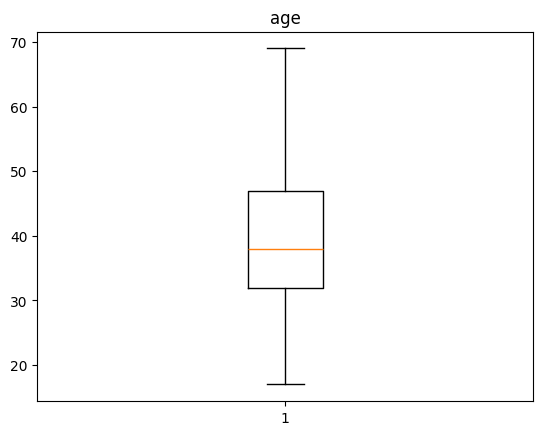

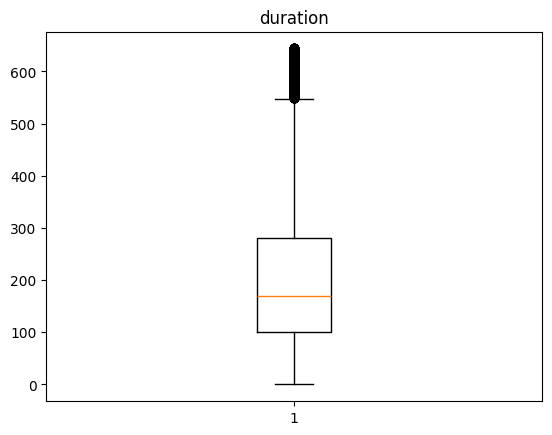

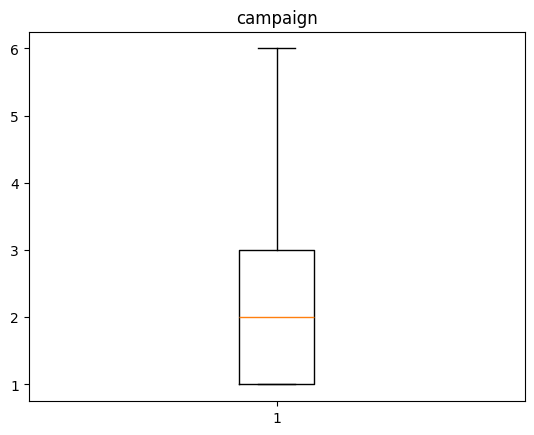

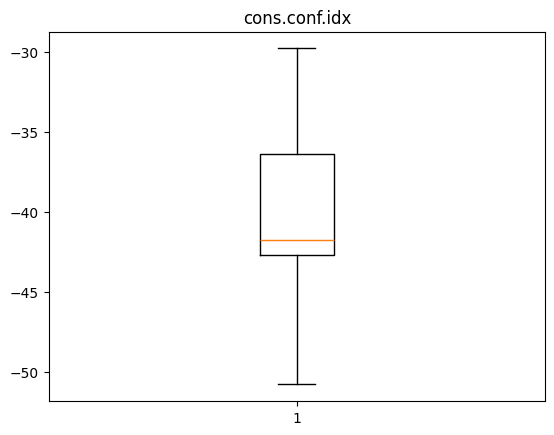

In [ ]:
for x in out_list:
  plt.boxplot(df[x])
  plt.title(x)
  plt.show()

In [ ]:
df.shape

(35165, 21)

Feature selection

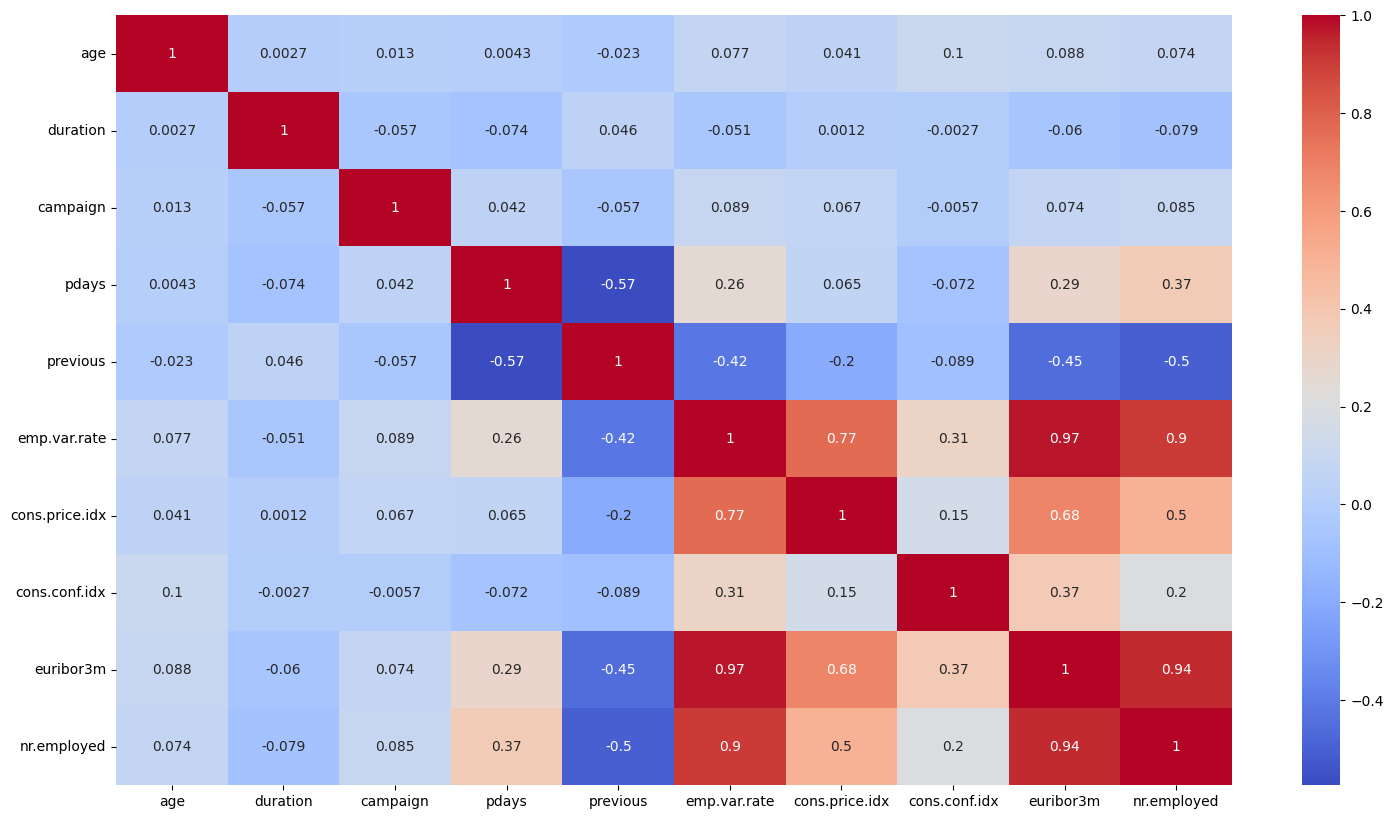

In [ ]:
fig = plt.figure(figsize=(18,10))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.show()

In [ ]:
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56.0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57.0,services,married,high.school,unknown,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37.0,services,married,high.school,no,yes,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40.0,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56.0,services,married,high.school,no,no,yes,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41181,37.0,admin.,married,university.degree,no,yes,no,cellular,nov,fri,...,1.0,999.0,0.0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41182,29.0,unemployed,single,basic.4y,no,yes,no,cellular,nov,fri,...,1.0,9.0,1.0,success,-1.1,94.767,-50.8,1.028,4963.6,no
41184,46.0,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1.0,999.0,0.0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56.0,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2.0,999.0,0.0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no


In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
le = LabelEncoder()
for x in df.columns:
  if df[x].dtype=='object':
    df[x]=le.fit_transform(df[x])
    print(le.classes_,le.transform(le.classes_))
    print()

['admin.' 'blue-collar' 'entrepreneur' 'housemaid' 'management' 'retired'
 'self-employed' 'services' 'student' 'technician' 'unemployed' 'unknown'] [ 0  1  2  3  4  5  6  7  8  9 10 11]

['divorced' 'married' 'single' 'unknown'] [0 1 2 3]

['basic.4y' 'basic.6y' 'basic.9y' 'high.school' 'illiterate'
 'professional.course' 'university.degree' 'unknown'] [0 1 2 3 4 5 6 7]

['no' 'unknown' 'yes'] [0 1 2]

['no' 'unknown' 'yes'] [0 1 2]

['no' 'unknown' 'yes'] [0 1 2]

['cellular' 'telephone'] [0 1]

['apr' 'aug' 'dec' 'jul' 'jun' 'mar' 'may' 'nov' 'oct' 'sep'] [0 1 2 3 4 5 6 7 8 9]

['fri' 'mon' 'thu' 'tue' 'wed'] [0 1 2 3 4]

['failure' 'nonexistent' 'success'] [0 1 2]

['no' 'yes'] [0 1]



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35165 entries, 0 to 41186
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             35165 non-null  float64
 1   job             35165 non-null  int64  
 2   marital         35165 non-null  int64  
 3   education       35165 non-null  int64  
 4   default         35165 non-null  int64  
 5   housing         35165 non-null  int64  
 6   loan            35165 non-null  int64  
 7   contact         35165 non-null  int64  
 8   month           35165 non-null  int64  
 9   day_of_week     35165 non-null  int64  
 10  duration        35165 non-null  float64
 11  campaign        35165 non-null  float64
 12  pdays           35165 non-null  float64
 13  previous        35165 non-null  float64
 14  poutcome        35165 non-null  int64  
 15  emp.var.rate    35165 non-null  float64
 16  cons.price.idx  35165 non-null  float64
 17  cons.conf.idx   35165 non-null  floa

In [ ]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]
X

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,56.0,3,1,0,0,0,0,1,6,1,261.0,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0
1,57.0,7,1,3,1,0,0,1,6,1,149.0,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0
2,37.0,7,1,3,0,2,0,1,6,1,226.0,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0
3,40.0,0,1,1,0,0,0,1,6,1,151.0,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0
4,56.0,7,1,3,0,0,2,1,6,1,307.0,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41181,37.0,0,1,6,0,2,0,0,7,0,281.0,1.0,999.0,0.0,1,-1.1,94.767,-50.8,1.028,4963.6
41182,29.0,10,2,0,0,2,0,0,7,0,112.0,1.0,9.0,1.0,2,-1.1,94.767,-50.8,1.028,4963.6
41184,46.0,1,1,5,0,0,0,0,7,0,383.0,1.0,999.0,0.0,1,-1.1,94.767,-50.8,1.028,4963.6
41185,56.0,5,1,6,0,2,0,0,7,0,189.0,2.0,999.0,0.0,1,-1.1,94.767,-50.8,1.028,4963.6


In [ ]:
y

,y
0,0
1,0
2,0
3,0
4,0
...,...
41181,1
41182,0
41184,0
41185,0


# RFE (Recursive Feature Elimnination)

It's feature selection technique.

It trains the model

Ranks the feature by importance

Repeats the process recursively

Stops when the desired number of features are selected

It's going to mark the unimportant column as False

Important columns as True


In [ ]:
from sklearn.feature_selection import RFE

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
model = LogisticRegression(max_iter=1000)

In [ ]:
rfe = RFE(model)

In [ ]:
rfe.fit(X,y)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

/usr/local/lib/python3.11/dist-packages/sklearn/

RFE(estimator=LogisticRegression(max_iter=1000))

In [ ]:
rfe.support_

array([False, False,  True,  True,  True, False, False,  True, False,
        True, False,  True, False,  True,  True, False, False,  True,
        True, False])

In [ ]:
selected_indexes = []

for i, data in enumerate(rfe.support_):
  if data==True:
    selected_indexes.append(i)

In [ ]:
selected_indexes

[2, 3, 4, 7, 9, 11, 13, 14, 17, 18]

In [ ]:
li = ['Feature1', 'Feature2','Feature3', 'Feature4']
for i, x in enumerate(li):
  if x=='Feature3':
    print(i)

2


In [ ]:
selected_indexes

[2, 3, 4, 7, 9, 11, 13, 14, 17, 18]

In [ ]:
dummy = df.iloc[:,selected_indexes]
dummy

,marital,education,default,contact,day_of_week,campaign,previous,poutcome,cons.conf.idx,euribor3m
0,1,0,0,1,1,1.0,0.0,1,-36.4,4.857
1,1,3,1,1,1,1.0,0.0,1,-36.4,4.857
2,1,3,0,1,1,1.0,0.0,1,-36.4,4.857
3,1,1,0,1,1,1.0,0.0,1,-36.4,4.857
4,1,3,0,1,1,1.0,0.0,1,-36.4,4.857
...,...,...,...,...,...,...,...,...,...,...
41181,1,6,0,0,0,1.0,0.0,1,-50.8,1.028
41182,2,0,0,0,0,1.0,1.0,2,-50.8,1.028
41184,1,5,0,0,0,1.0,0.0,1,-50.8,1.028
41185,1,6,0,0,0,2.0,0.0,1,-50.8,1.028


In [ ]:
X = dummy
X

,marital,education,default,contact,day_of_week,campaign,previous,poutcome,cons.conf.idx,euribor3m
0,1,0,0,1,1,1.0,0.0,1,-36.4,4.857
1,1,3,1,1,1,1.0,0.0,1,-36.4,4.857
2,1,3,0,1,1,1.0,0.0,1,-36.4,4.857
3,1,1,0,1,1,1.0,0.0,1,-36.4,4.857
4,1,3,0,1,1,1.0,0.0,1,-36.4,4.857
...,...,...,...,...,...,...,...,...,...,...
41181,1,6,0,0,0,1.0,0.0,1,-50.8,1.028
41182,2,0,0,0,0,1.0,1.0,2,-50.8,1.028
41184,1,5,0,0,0,1.0,0.0,1,-50.8,1.028
41185,1,6,0,0,0,2.0,0.0,1,-50.8,1.028


In [ ]:
y

,y
0,0
1,0
2,0
3,0
4,0
...,...
41181,1
41182,0
41184,0
41185,0


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=0)

In [ ]:
x_train.shape

(28132, 10)

In [ ]:
y_train.shape

(28132,)

In [ ]:
x_test.shape

(7033, 10)

In [ ]:
y_test.shape

(7033,)

In [ ]:
lr = LogisticRegression(max_iter=1000)

In [ ]:
lr.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = lr.predict(x_test)

In [ ]:
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
accuracy_score(y_pred,y_test)*100

93.2176880420873

In [ ]:
confusion_matrix(y_pred,y_test)

array([[6450,  426],
       [  51,  106]])

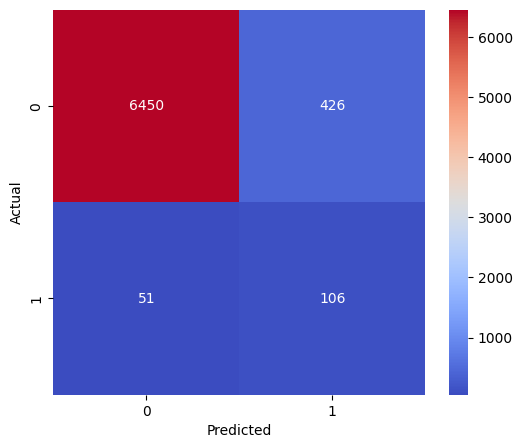

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_pred,y_test),annot=True,cmap='coolwarm',fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
x_test

,marital,education,default,contact,day_of_week,campaign,previous,poutcome,cons.conf.idx,euribor3m
34348,1,3,0,0,2,1.0,0.0,1,-46.2,1.266
28335,1,5,1,0,4,1.0,0.0,1,-47.1,1.445
19370,1,0,1,0,4,1.0,0.0,1,-36.1,4.967
16719,1,5,0,0,4,2.0,0.0,1,-42.7,4.963
631,2,6,0,1,3,1.0,0.0,1,-36.4,4.857
...,...,...,...,...,...,...,...,...,...,...
31691,1,0,1,0,2,1.0,1.0,0,-46.2,1.327
612,2,0,0,1,3,1.0,0.0,1,-36.4,4.857
21913,1,6,0,0,4,2.0,0.0,1,-36.1,4.964
22453,1,7,0,0,0,4.0,0.0,1,-36.1,4.964


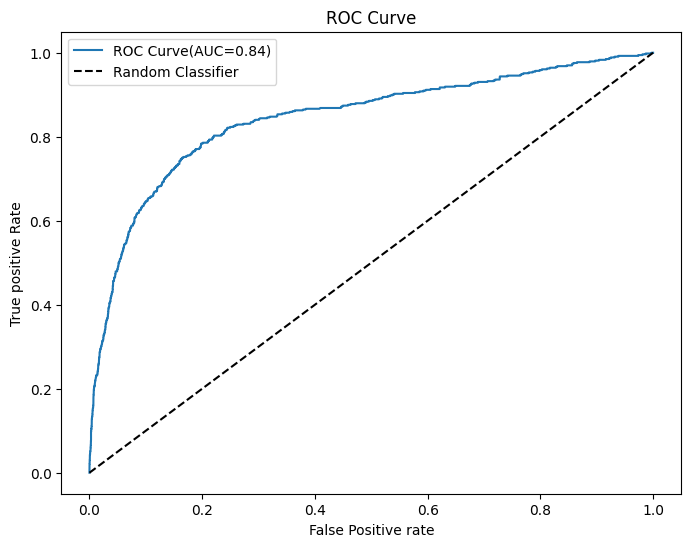

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
y_probs = lr.predict_proba(x_test)[:,1]

fpr, tpr, threshold = roc_curve(y_test,y_probs)
auc = roc_auc_score(y_test,y_probs)

plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,label=f'ROC Curve(AUC={auc:.2f})')
plt.plot([0,1],[0,1],'k--',label='Random Classifier')
plt.xlabel('False Positive rate')
plt.ylabel('True positive Rate')
plt.legend()
plt.title('ROC Curve')
plt.show()